# Interprétations cProfile

1. Les résultats de latence


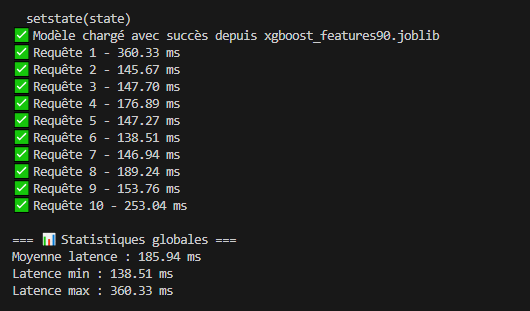


Cela indique que le endpoint FastAPI /status_client_individuel répond :

en moyenne en ~186 ms (ce qui est très correct),

avec une latence minimale d’environ 138 ms,

et un pic maximum à 360 ms (la 1ère requête, souvent plus lente à cause du chargement initial du modèle).

2. Profilage

De la fonction la plus coûteuse à la moins coûteuse (du haut vers le bas)


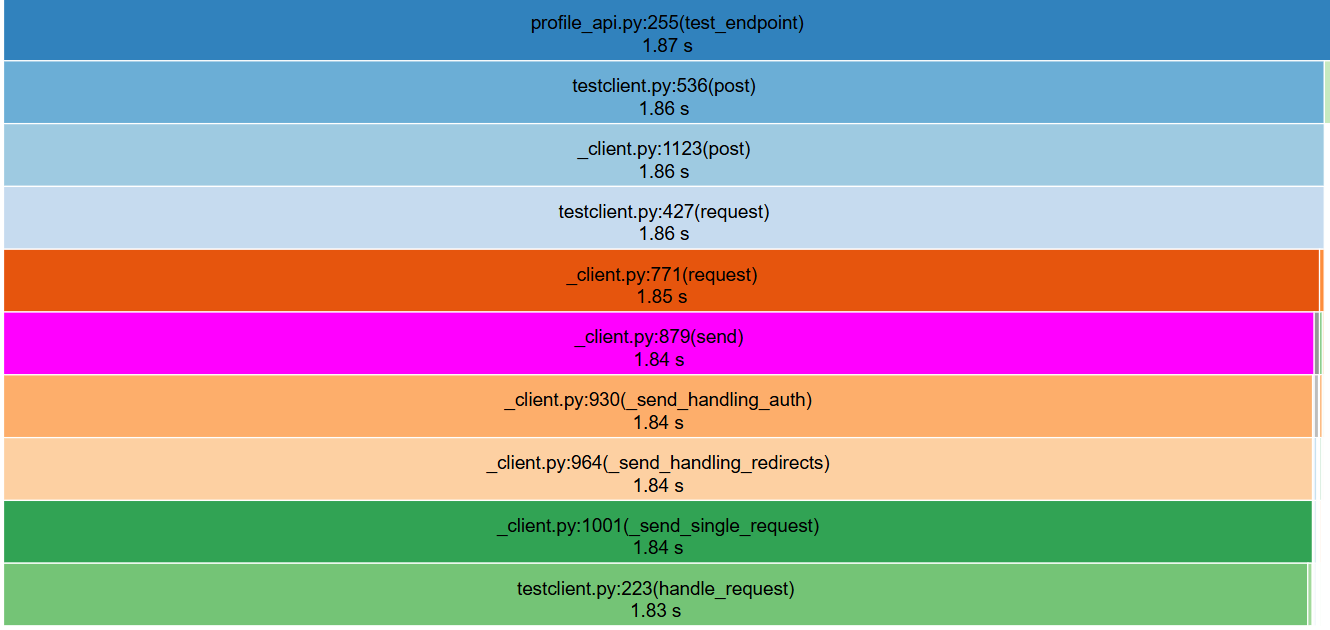

⚙️ 2. Rôle des principales fonctions

Voici à quoi correspond chacune (avec FastAPI + HTTPX sous le capot) :

| Fonction                                       | Rôle dans le processus                                                                   |
| ---------------------------------------------- | ---------------------------------------------------------------------------------------- |
| **`profile_api.py:255(test_endpoint)`**        | C’est le test principal. Il appelle la fonction `client.post()` pour tester l'API.    |
| **`testclient.py:536(post)`**                  | Méthode `post()` du `TestClient` (FastAPI / Starlette) qui prépare et envoie la requête. |
| **`_client.py:1123(post)`**                    | Méthode interne d’`httpx.Client` pour envoyer la requête HTTP POST.                      |
| **`testclient.py:427(request)`**               | Convertit les paramètres Python (`json`, `headers`, etc.) en véritable requête HTTP.     |
| **`_client.py:771(request)`**                  | Point d’entrée de la requête côté client (`send`, `prepare`, etc.).                      |
| **`_client.py:879(send)`**                     | Gère réellement l’envoi de la requête (réseau ou requête simulée).                       |
| **`_client.py:930(_send_handling_auth)`**      | Ajoute les informations d’authentification si besoin.                                    |
| **`_client.py:964(_send_handling_redirects)`** | Suit les éventuelles redirections HTTP (302, etc.).                                      |
| **`_client.py:1001(_send_single_request)`**    | Exécute une seule requête HTTP “finale”.                                                 |
| **`testclient.py:223(handle_request)`**        | Capture la requête et la passe au serveur FastAPI (en interne).                          |


**Valeurs détaillées** 

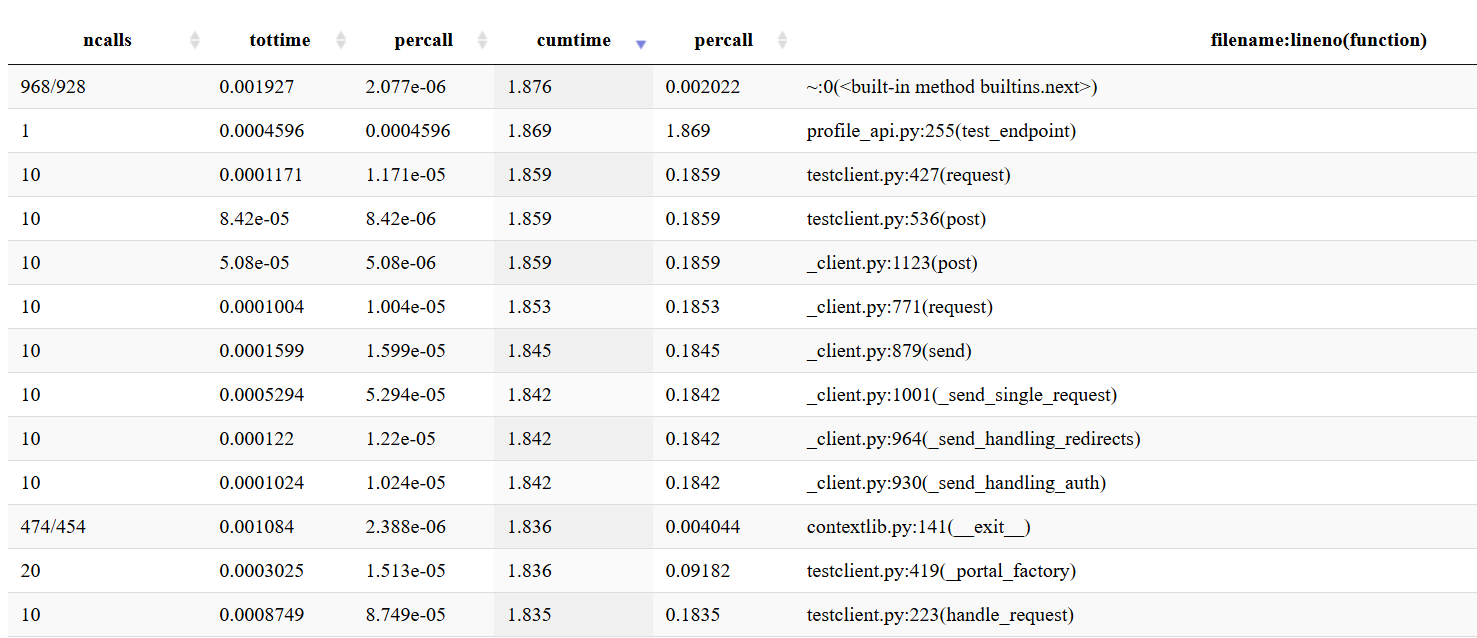

| Colonne                     | Signification                                             |
| --------------------------- | --------------------------------------------------------- |
| `ncalls`                    | Nombre d’appels de la fonction                            |
| `tottime`                   | Temps total passé **dans la fonction elle-même**          |
| `percall`                   | `tottime / ncalls`                                        |
| `cumtime`                   | Temps total passé dans la fonction **et ses sous-appels** |
| `percall (cum)`             | `cumtime / ncalls`                                        |
| `filename:lineno(function)` | Où la fonction est définie                                |
